<a href="https://colab.research.google.com/github/Saransh6045/Machine_Learning/blob/main/Building_Linear_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Equations

Y = wX + b

- Y = Dependent variable
- X = Independent - Variable
- w = Weight
- b = Bias

**Gradient Descent:**

It is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

- w = w - L*dw
- b = b - L*db

**Learning Rate:**

It is a tuning parameter in optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.


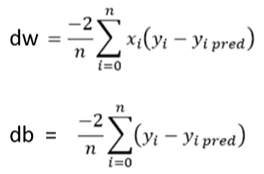

In [1]:
#Importing the libraries
import numpy as np

**Linear Regression**

In [2]:
class Linear_Regression():

  def __init__(self, learning_rate, no_of_iterations):

    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations

  def fit(self, X, Y):
    self.m, self.n = X.shape
    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

    for i in range(self.no_of_iterations):
      self.update_weights()

  def update_weights(self):
    Y_prediction = self.predict(self.X)

    dw = - (2*(self.X.T).dot(self.Y - Y_prediction)) / self.m
    db = - (2*np.sum(self.Y - Y_prediction)) / self.m

    self.w = self.w - self.learning_rate * dw
    self.b = self.b - self.learning_rate * db

  def predict(self, X):
    return X.dot(self.w) + self.b


```
class Linear_Regression()
```




Creates a new data type just like int, float, list. Now Linear_Regression is created.

The empty parenthesis () mean that it does not inherit from another class.

It is like defining our own LinearRegression Model.

`__init__`

Calls a constructor to initialize the hyperparameter and runs automatically when you create an object.

`**self**`

It is the current instance of the model on which the method is being called.

It is used to store variables inside the class so that all the methods can access them.



```
learning_rate
```


The learning rate defines how much step we have to take at one time for weights and bias.

Controls how big step a gradient descent takes.*italicized text*

Too large → overshoot

Too small → very slow learning

`no_of_iterations`

Number of times gradient descent will run.



```
self.learning_rate = learning_rate
self.no_of_iterations = no_of_iterations
```



It indicates that the variable is stored inside the object and is accessible anywhere in the class.

Why self.?

Without self, the variable dies after __init__ ends.


```
def fit(self, X, Y):
```


fit: Trains the model.

X: Input features (independent variables)


*   Shape = (m,n) where m = number of samples and n = number of features

Y: Target Values (dependent variables)


*   Shape = (m, )



`self.m, self.n = X.shape`

X.shape returen rows and columns. So, self.m represents the number of data points and self.n represents the number of features.



```
self.w = np.zeros(self.n)
self.b = 0
```



self.w represents the weiggh per feature. So its size would be same as the feature one. Initialized to zero.


*   Shape = (n, )

self.b represents the bias value. It is a single scalar value. Initialized to zero.




```
self.X = X
self.Y = Y
```



Data is stored inside the object so that the other methods can access them.



```
for i in range(self.no_of_iterations):
    self.update_weights()
```



It is a gradient descent loop which helps in updating weights and bias repeatedly. The number of iterations is controlled by the variable self.no_of_iterations.





```
def update_weights:
```


A method for updating the weights.



```
Y_prediction = self.predict(self.X)
```


It is used to predict the output for the current weight and bias.



```
dw = (2*(self.X.T).dot(self.Y - Y_prediction)) / self.m
db = db = - (2*np.sum(self.Y - Y_prediction)) / self.m
```

self.Y - Y_prediction: Error residual

self.X.T: Compute transpose of X and shape is (n,m)

dot: Does matrix multiplication.

Same below in the caase of bias.







```
self.w = self.w - self.learning_rate * dw
self.b = self.b - self.learning_rate * db
```

Updates the weights and bias values.





```
def predict(self, X):
    return X.dot(self.w) + self.b
```

Predicts the values on training or new data.


# Using Linear Regression Model for Prediction

In [3]:
#importing the dependencies
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Data Pre-processing

In [4]:
#loading the data from csv to a pandas dataframe
salary_data = pd.read_csv('/content/drive/MyDrive/Copy of salary_data.csv')

In [5]:
#printing the first five and last five columns of the dataframe
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [6]:
salary_data.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [7]:
#number of rows and columns
salary_data.shape

(30, 2)

In [8]:
#checking for missing values
salary_data.isnull().sum()

,0
YearsExperience,0
Salary,0


Splitting features and targets

In [9]:
x = salary_data.drop(columns='Salary', axis=1)
y = salary_data['Salary']

In [10]:
print(x)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [11]:
print(y)

0      39343
1      46205
2      37731
3      43525
4      39891
5      56642
6      60150
7      54445
8      64445
9      57189
10     63218
11     55794
12     56957
13     57081
14     61111
15     67938
16     66029
17     83088
18     81363
19     93940
20     91738
21     98273
22    101302
23    113812
24    109431
25    105582
26    116969
27    112635
28    122391
29    121872
Name: Salary, dtype: int64


Splitting the dataset into training and test data

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=2)

Training the Linear Regression Model

In [13]:
model = Linear_Regression(learning_rate=0.02, no_of_iterations=1000)

In [14]:
model.fit(x_train, y_train)

In [15]:
#printing the model parameter values

print('weight = ', model.w[0])
print('bias = ', model.b)

weight =  9534.934692142133
bias =  23735.972514255136


/tmp/ipython-input-860843048.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('weight = ', model.w[0])


Salary = weight*experience + bias

Evaluating the model by predicting salary for test data

In [16]:
y_predicted = model.predict(x_test)

In [17]:
print(y_predicted)

1      36131.387614
0      34224.400676
14     66643.178629
9      59015.230875
21     91434.008828
19     80945.580667
23    101922.436990
6      52340.776591
3      42805.841899
dtype: float64


Visualizing the predictewd values & actual values

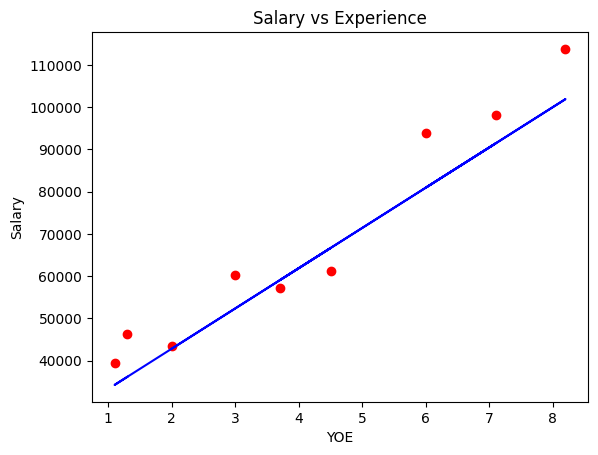

In [18]:
plt.scatter(x_test, y_test, color='red')
plt.plot(x_test, y_predicted, color='blue')
plt.xlabel('YOE')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()